# RF-GenLab — Demo

Deep generative models for **synthetic RF signal generation and anomaly detection** (ECE 1508 project).

This notebook walks through sample **input → output** behaviour:
1. synthesise protocol-like RF signals (Wi-Fi / BLE / ZigBee) and view their spectrograms,
2. synthesise anomalies (heavy noise, frequency shift, timing corruption, protocol mixing),
3. load the three trained generative models (Conditional VAE, RealNVP flow, Conditional DDPM),
4. draw class-conditional generated samples, and
5. run likelihood-based anomaly detection.

> **Prerequisite:** run `python scripts/run_all.py` once (builds the dataset and trains all models) so the checkpoints in `runs/` exist.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
import numpy as np
import torch
import matplotlib.pyplot as plt

from rfgen.utils import load_config, get_device
from rfgen.dsp.generators import CLASS_NAMES
from rfgen.dsp.impairments import make_normal, make_anomaly
from rfgen.dsp.spectrogram import SpectrogramConfig, iq_to_spectrogram

cfg = load_config('../configs/default.yaml')
device = get_device()
fs = float(cfg['signal']['sample_rate_hz'])
n = int(cfg['signal']['num_samples'])
sc = SpectrogramConfig.from_config(cfg)
rng = np.random.default_rng(0)
print('device:', device, '| classes:', CLASS_NAMES, '| spectrogram:', (sc.n_freq, sc.n_time))

device: cuda | classes: ['wifi', 'ble', 'zigbee'] | spectrogram: (32, 32)


## 1. Synthesise RF signals and view spectrograms

Each signal is a `num_samples` complex baseband I/Q window turned into a `1×32×32` log-magnitude STFT spectrogram, peak-normalised to `[0, 1]`.

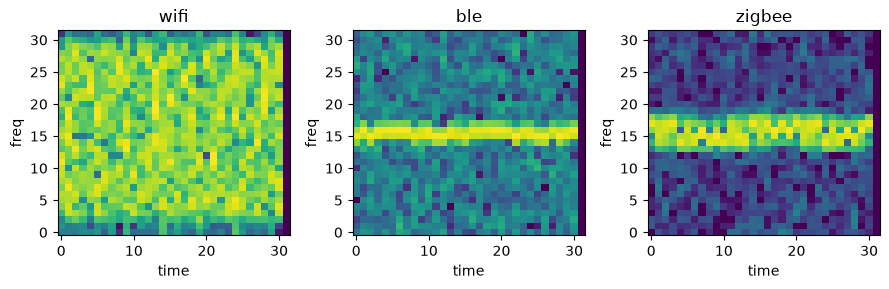

In [2]:
fig, ax = plt.subplots(1, 3, figsize=(9, 3))
for i, cls in enumerate(CLASS_NAMES):
    sp = iq_to_spectrogram(make_normal(cls, n, fs, rng, cfg), sc)
    ax[i].imshow(sp[0], origin='lower', aspect='auto', cmap='viridis', vmin=0, vmax=1)
    ax[i].set_title(cls); ax[i].set_xlabel('time'); ax[i].set_ylabel('freq')
plt.tight_layout(); plt.show()

## 2. Synthesise anomalies

Anomalies are valid signals pushed out of distribution: buried in noise, shifted to the band edge, timing-corrupted, or two protocols mixed together.

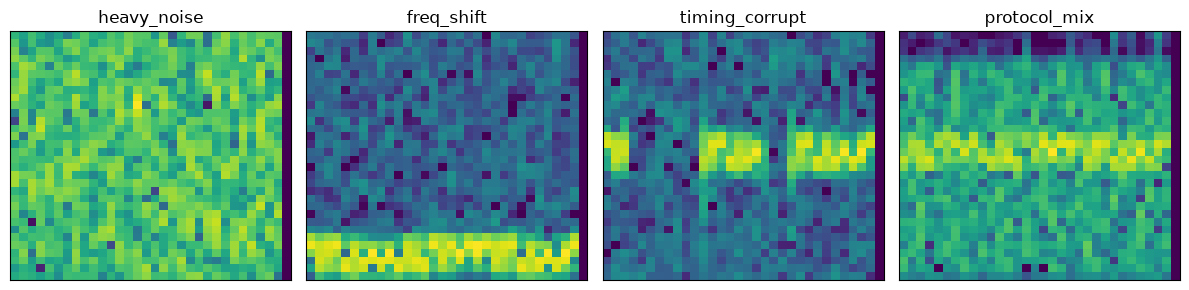

In [3]:
atypes = cfg['data']['anomaly_types']
fig, ax = plt.subplots(1, len(atypes), figsize=(3 * len(atypes), 3))
for i, a in enumerate(atypes):
    sp = iq_to_spectrogram(make_anomaly(a, n, fs, rng, cfg), sc)
    ax[i].imshow(sp[0], origin='lower', aspect='auto', cmap='viridis', vmin=0, vmax=1)
    ax[i].set_title(a); ax[i].set_xticks([]); ax[i].set_yticks([])
plt.tight_layout(); plt.show()

## 3. Load the trained generative models

In [4]:
from rfgen.eval.common import load_all, min_class_score
models, clf = load_all(cfg, device)
print('loaded:', list(models.keys()), '+ classifier')

loaded: ['vae', 'flow', 'diffusion'] + classifier


## 4. Class-conditional generation

Each model is asked to generate a spectrogram for a chosen protocol class. Real (top) vs. generated rows.

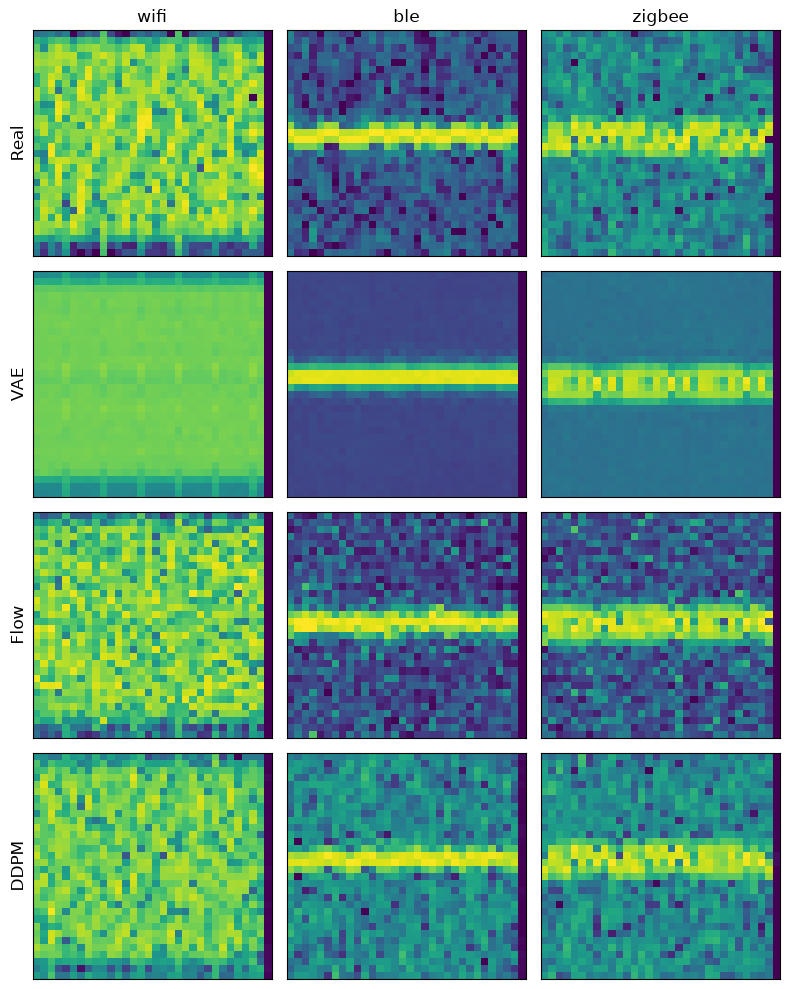

In [5]:
fig, ax = plt.subplots(4, 3, figsize=(8, 10))
rows = ['Real', 'VAE', 'Flow', 'DDPM']
for c, cls in enumerate(CLASS_NAMES):
    ax[0, c].imshow(iq_to_spectrogram(make_normal(cls, n, fs, rng, cfg), sc)[0],
                    origin='lower', aspect='auto', cmap='viridis', vmin=0, vmax=1)
    ax[0, c].set_title(cls)
    y = torch.tensor([c], device=device)
    for r, tag in enumerate(['vae', 'flow', 'diffusion'], start=1):
        with torch.no_grad():
            s = models[tag].sample(1, y).cpu().numpy()[0, 0]
        ax[r, c].imshow(s, origin='lower', aspect='auto', cmap='viridis', vmin=0, vmax=1)
    for r in range(4):
        ax[r, c].set_xticks([]); ax[r, c].set_yticks([])
for r, lab in enumerate(rows):
    ax[r, 0].set_ylabel(lab, fontsize=12)
plt.tight_layout(); plt.show()

## 5. Anomaly detection

Anomaly score = `min_y (-log p(x | y))` under the flow (its exact negative log-likelihood, minimised over the known classes). We calibrate a threshold on normal signals, then evaluate on a fresh batch of clean + anomalous signals.

threshold=-807.3  ROC-AUC=0.983  accuracy@thr=0.943


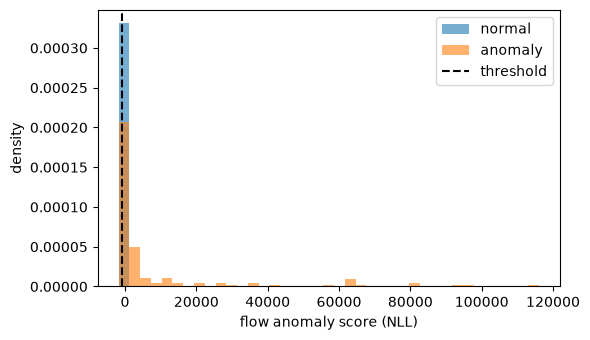

In [6]:
from sklearn.metrics import roc_auc_score
nc = len(CLASS_NAMES)
cal = np.stack([iq_to_spectrogram(make_normal(rng.choice(CLASS_NAMES), n, fs, rng, cfg), sc) for _ in range(400)])
thr = float(np.percentile(min_class_score(models['flow'], 'flow', cal, nc, device), 95))

clean = np.stack([iq_to_spectrogram(make_normal(CLASS_NAMES[i % nc], n, fs, rng, cfg), sc) for i in range(150)])
anom = np.stack([iq_to_spectrogram(make_anomaly(atypes[i % len(atypes)], n, fs, rng, cfg), sc) for i in range(150)])
sc_clean = min_class_score(models['flow'], 'flow', clean, nc, device)
sc_anom = min_class_score(models['flow'], 'flow', anom, nc, device)
auc = roc_auc_score(np.r_[np.zeros(150), np.ones(150)], np.r_[sc_clean, sc_anom])
acc = np.r_[sc_clean <= thr, sc_anom > thr].mean()
print(f'threshold={thr:,.1f}  ROC-AUC={auc:.3f}  accuracy@thr={acc:.3f}')

plt.figure(figsize=(6, 3.5))
b = np.linspace(np.percentile(np.r_[sc_clean, sc_anom], 1), np.percentile(np.r_[sc_clean, sc_anom], 99), 40)
plt.hist(sc_clean, bins=b, alpha=0.6, label='normal', density=True)
plt.hist(sc_anom, bins=b, alpha=0.6, label='anomaly', density=True)
plt.axvline(thr, color='k', ls='--', label='threshold')
plt.xlabel('flow anomaly score (NLL)'); plt.ylabel('density'); plt.legend(); plt.tight_layout(); plt.show()

## 6. Full results summary

The complete quantitative comparison (all three models, all metrics) produced by the evaluation pipeline:

In [7]:
from pathlib import Path
p = Path('../results/summary.md')
print(p.read_text(encoding='utf-8') if p.exists() else 'Run scripts/run_all.py first.')

## Results summary

| Model | Family | Anomaly AUC | Anomaly AP | Gen. acc. | Frechet | Likelihood metric |
|---|---|---|---|---|---|---|
| Conditional VAE | latent-variable | 0.846 | 0.869 | 1.000 | 0.175 | 0.728 bpd (ELBO bound) |
| RealNVP flow | explicit likelihood | 0.983 | 0.985 | 1.000 | 0.235 | -1.486 bpd (exact) |
| Conditional DDPM | denoising | 0.972 | 0.977 | 1.000 | 0.157 | 0.103 denoise MSE |
| Mamba (I/Q AR) | autoregressive | 0.829 | 0.842 | 1.000 | 2.530 | 5.399 bpd (exact discrete) |

### Anomaly-detection AUC by corruption type

| Model | heavy_noise | freq_shift | timing_corrupt | protocol_mix |
|---|---|---|---|---|
| Conditional VAE | 0.869 | 0.945 | 0.751 | 0.819 |
| RealNVP flow | 0.951 | 1.000 | 0.998 | 0.984 |
| Conditional DDPM | 0.936 | 1.000 | 0.996 | 0.956 |
| Mamba (I/Q AR) | 0.912 | 0.987 | 0.731 | 0.688 |

### Model size and training time

| Model | Params | Train time (s) |
|---|---|---|
| Conditional VAE | 596,065 | 8.6 |
| RealNVP flow | 6,901,856 | 

**Takeaway.** All three models generate recognisable class-conditional spectrograms, but they differ on anomaly detection: the explicit-likelihood **RealNVP flow** is the strongest detector, the **DDPM** is close behind and produces the most realistic samples, and the **VAE** is cheapest but weakest (and visibly over-smoothed).